In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from wassa_functions import allen_reconstruction_comparison
from dataset_generation import kfold_dataset, make_allen_dataset
from wassa_plots import make_violin, plot_results
from wassa_metrics import WassDist
from wassa_training import get_training_parameters, learn_motifs
import matplotlib.pyplot as plt
import scipy, torch, glob
import numpy as np
from wassa import WassA
from tqdm.notebook import tqdm

In [3]:
dataset_name = 'allen_data_by_image'
device = 'cpu'
dataset_path = '../../'+dataset_name+'/*'
saving_path = '../results/wassa_allen_'
metric_names = ['training loss', 'testing loss', 'activations', 'explained variance']

In [4]:
training_parameters_emd = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'emd',
    'activation' : 'emd like',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .01,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True,
}

In [5]:
training_parameters_mse = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : True
}

In [6]:
training_parameters_frs = {
    'kernel_size' : (1, 1, 1),
    'loss_type' : 'mse',
    'activation' : 'conv',
    'sigmoid' : False,
    'kernels_norm' : 2,
    'N_learnsteps' : 2000,
    'learning_rate' : .05,
    'penalty_type' : [None],
    'lambda' : [0],
    'batch_size' : None,
    'do_bias' : False,
    'weight_init' : 'flat',
    'normalize_input' : False
}

In [7]:

frs = False
training_parameters = training_parameters_emd

mse_loss = torch.nn.MSELoss(reduction='none')
emd_loss = WassDist(zeros='same',normalize=True, reduction = 'none')

all_trainsets, all_testsets, all_othersets = make_allen_dataset(dataset_path, device=device)
ind = torch.randint(len(all_trainsets),[1]).item()

if frs:
    training_set, testing_set, othersets = all_trainsets[ind].mean(dim=-1).unsqueeze(-1).to(device), all_testsets[ind].mean(dim=-1).unsqueeze(-1).to(device), all_othersets[ind].mean(dim=-1).unsqueeze(-1).to(device)
else:
    training_set, testing_set, othersets = all_trainsets[ind].to(device), all_testsets[ind].to(device), all_othersets[ind].to(device)

num_samples, num_neurons, num_timesteps = training_set.shape
training_parameters['kernel_size'] = (1,num_neurons, num_timesteps)
model = WassA(training_parameters,device=device)
model_name = saving_path+dataset_name+str(ind)+get_training_parameters(training_parameters)
model, training_metrics, _ = learn_motifs(model,training_set,testing_set,training_parameters,model_name,metric_names,None)
if training_parameters['normalize_input']:
    testing_set = torch.nn.functional.normalize(testing_set, p=1, dim=2)
factors_testing, testingset_hat = model(testing_set)
factors_others, otherset_hat = model(othersets)
mse_losses_id  = mse_loss(testingset_hat,testing_set).mean(axis=(1,2)).detach()
emd_losses_id  = emd_loss(testingset_hat,testing_set).mean(axis=(1,2)).detach()
mse_losses_ood  = mse_loss(otherset_hat,othersets).mean(axis=(1,2)).detach()
emd_losses_ood  = emd_loss(otherset_hat,othersets).mean(axis=(1,2)).detach()
print(mse_losses_id, mse_losses_ood, emd_losses_id, emd_losses_ood)

../results/wassa_allen_allen_data_by_image2871259250emdemd likeFalse220000.01None0NoneFalseflatTrue00
tensor([0.0012, 0.0010]) tensor([0.0120, 0.0110]) tensor([0.1882, 0.2159]) tensor([0.2028, 0.2076])


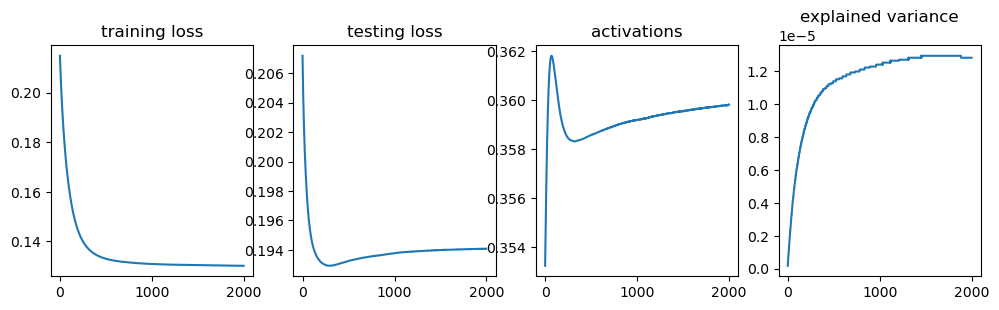

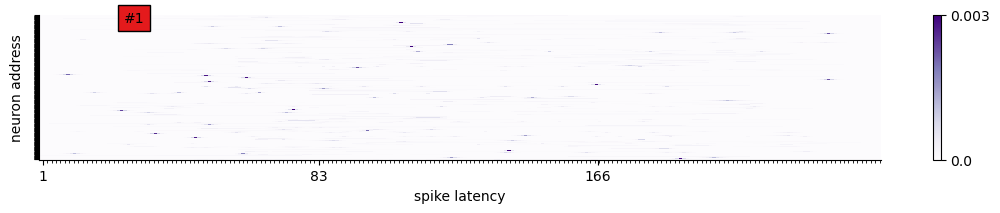

In [8]:
plot_results(training_metrics, metric_names, model, training_set[0], model=None, spike_times = None)

In [9]:
def classifier(dataset_name, training_parameters, metric_names, frs=False, shuffle_spikes=False, saving_path = 'results/allen_',device='cpu'):

    mse_loss = torch.nn.MSELoss(reduction='none')
    emd_loss = WassDist(zeros='same',normalize=True, reduction = 'none')

    dataset_path = '../../'+dataset_name+'/*'

    all_trainsets, _, _ = make_allen_dataset(dataset_path, device=device)
    number_folds, number_animals, number_images, number_repetitions = 5, 32, 20, 10
    all_mse, all_emd = torch.zeros([number_folds,number_animals,number_images,number_images*2]), torch.zeros([number_folds,number_animals,number_images,number_images*2])
    all_weights, all_frs = [], []
    
    dec_score_emd, dec_score_mse = [], []
    for fold in range(number_folds):
        all_testsets, labels = make_allen_testsets_for_decoding(dataset_path,fold_ind=fold,shuffle_spikes=shuffle_spikes,device=device)
        all_weights_fold = []
        all_frs_fold = []
        for ind_animal in tqdm(range(number_animals)):
    
            ind_images = labels[ind_animal]
    
            if frs:
                testing_set = all_testsets[ind_animal].mean(dim=-1).unsqueeze(-1)
            else:
                testing_set = all_testsets[ind_animal]
    
            mse_losses, emd_losses, corr = torch.zeros([20,40]), torch.zeros([20,40]), torch.zeros([20,40])
    
            num_samples, num_neurons, num_timesteps = testing_set.shape
            training_parameters['kernel_size'] = (1,num_neurons, num_timesteps)
            weights_animal = torch.zeros([number_images,num_neurons,num_timesteps])
            frs_animal = torch.zeros([number_images,num_neurons])
            for image in range(number_images):
                ind_trainset = int(ind_animal*100+image*5+fold)
                if frs:
                    training_set = all_trainsets[ind_trainset].mean(dim=-1).unsqueeze(-1)
                else:
                    training_set = all_trainsets[ind_trainset]
                model = WassA(training_parameters,device=device)
                model_name = saving_path+dataset_name+str(ind_trainset)+get_training_parameters(training_parameters)
                model, training_metrics, _ = learn_motifs(model,training_set,testing_set,training_parameters,model_name,metric_names,None,verbose=False)
                if training_parameters['normalize_input']:
                    testing_set = torch.nn.functional.normalize(testing_set, p=1, dim=2)
                factors_testing, testingset_hat = model(testing_set)
            
                mse_losses[image]  = mse_loss(testingset_hat,testing_set).mean(axis=(1,2)).detach()
                emd_losses[image]  = emd_loss(testingset_hat,testing_set).mean(axis=(1,2)).detach()

                weights_animal[image] = model.weights.data[0]
                frs_animal[image] = training_set.mean(dim=(0,2))
    
            all_mse[fold,ind_animal] = mse_losses
            all_emd[fold,ind_animal] = emd_losses
            all_weights_fold += [weights_animal]
            all_frs_fold += [frs_animal]
        all_weights += [all_weights_fold]
        all_frs += [all_frs_fold]
        #dec_score_emd.append(compute_decoding_score(all_emd[fold*number_animals:(fold+1)*number_animals]))
        #dec_score_mse.append(compute_decoding_score(all_mse[fold*number_animals:(fold+1)*number_animals]))
        #print(f'percentage correct for EMD decoding: {dec_score_emd[fold].mean()} +- {dec_score_emd[fold].std()}')
        #print(f'percentage correct for MSE decoding: {dec_score_mse[fold].mean()} +- {dec_score_mse[fold].std()}')
    
    return all_mse, all_emd, all_weights, all_frs

In [10]:
def shuffle_spikes_random(spikes, dim=-1):
    """
    Randomly shuffle spikes along the time axis independently for each trial and neuron.
    spikes: (S x N x T) binary tensor of spike trains
    """
    S, N, T = spikes.shape
    shuffled = torch.zeros_like(spikes)

    for s in range(S):
        for n in range(N):
            # get indices of all time bins
            perm = torch.randperm(T)
            shuffled[s, n] = spikes[s, n, perm]

    return shuffled

def make_allen_testsets_for_decoding(dataset_path, number_samples_per_image=10, number_folds=5, fold_ind = 0, shuffle_spikes = False, device='cpu'):
    
    files_list = glob.glob(dataset_path)
    number_animals = len(files_list)
    all_trainsets, all_testsets = [], []
    id_image_by_animal = []

    for f in range(len(files_list)):
        data = torch.load(files_list[f], weights_only = True)
        data = data.to(torch.float32).to(device)
        if shuffle_spikes:
            data = shuffle_spikes_random(data.clone())
        number_samples, number_neurons, number_timesteps = data.shape
        number_images = number_samples//number_samples_per_image
        id_image, testsets_animal = [], []
        for image in range(number_images):
            trainsets, testsets, indices = kfold_dataset(data[image*number_samples_per_image:(image+1)*number_samples_per_image],k=number_folds)
            testsets_animal += testsets[fold_ind].unsqueeze(0)
            id_image += [image]*testsets[fold_ind].shape[0]
        id_image_by_animal += [id_image]
        all_testsets += [torch.cat(testsets_animal)]
            
    return all_testsets, id_image_by_animal

In [11]:
all_mse_emd, all_emd_emd, weights_emd, frs_emd = classifier(dataset_name,training_parameters_emd,metric_names,saving_path=saving_path,device=device)

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Text(0, 0.5, 'average firing rate for a specific neuron')

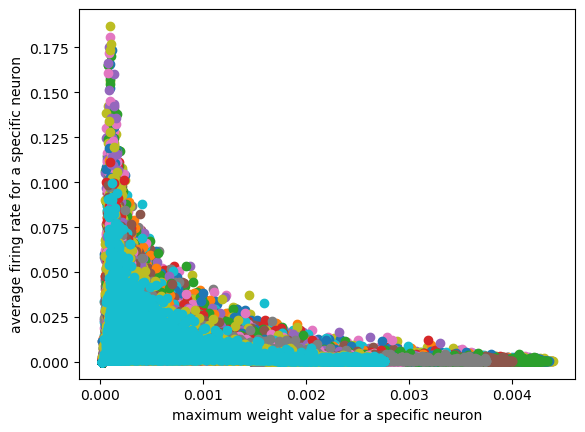

In [32]:
for f in range(5):
    for a in range(32):
        #print(weights_emd[f][a].max(dim=-1).shape,frs_emd[f][a].shape)
        plt.scatter(weights_emd[f][a].amax(dim=-1),frs_emd[f][a])
plt.xlabel('maximum weight value for a specific neuron')
plt.ylabel('average firing rate for a specific neuron')

In [165]:
all_mse_mse, all_mse_emd, weights_mse, _ = classifier(dataset_name,training_parameters_mse,metric_names,saving_path=saving_path,device=device)

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

In [13]:
all_mse_frs, all_emd_frs, weights_frs, _ = classifier(dataset_name,training_parameters_frs,metric_names,saving_path=saving_path,frs=True,device=device)

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

In [14]:
all_mse_emd_shuf, all_emd_emd_shuf, weights_emd, _ = classifier(dataset_name,training_parameters_emd,metric_names,saving_path=saving_path,shuffle_spikes=True,device=device)

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

In [15]:
all_mse_mse_shuf, all_emd_mse_shuf, weights_mse, _ = classifier(dataset_name,training_parameters_mse,metric_names,saving_path=saving_path,shuffle_spikes=True,device=device)

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

In [16]:
def decoding_accuracy(loss):
    number_folds, number_animals, number_aes, number_samples = loss.shape
    ind_hat = torch.argmin(loss,axis=2)
    true_ind = torch.arange(number_aes).repeat_interleave(2).unsqueeze(0).unsqueeze(0).repeat(number_folds,number_animals,1)
    correct = ind_hat == true_ind
    return correct.sum(axis=(2))/(number_samples)

Text(0, 0.5, 'decoding accuracy')

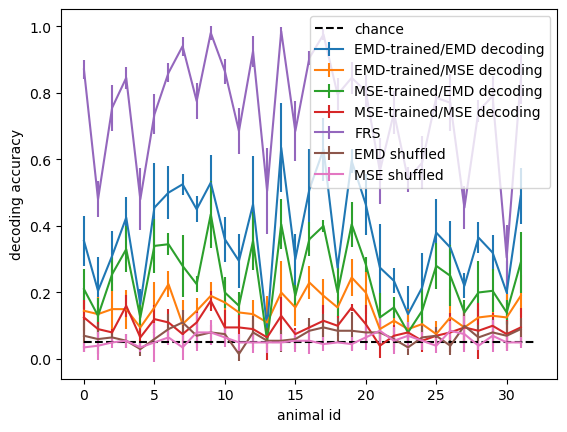

In [17]:
acc_emd_emd = decoding_accuracy(all_emd_emd)
number_animals = acc_emd_emd.shape[1]
plt.errorbar(torch.arange(number_animals),acc_emd_emd.mean(axis=0),acc_emd_emd.std(axis=0),label='EMD-trained/EMD decoding')
acc_mse_emd = decoding_accuracy(all_mse_emd)
plt.errorbar(torch.arange(number_animals),acc_mse_emd.mean(axis=0),acc_mse_emd.std(axis=0),label='EMD-trained/MSE decoding')
acc_emd_mse = decoding_accuracy(all_emd_mse)
plt.errorbar(torch.arange(number_animals),acc_emd_mse.mean(axis=0),acc_emd_mse.std(axis=0),label='MSE-trained/EMD decoding')
acc_mse_mse = decoding_accuracy(all_mse_mse)
plt.errorbar(torch.arange(number_animals),acc_mse_mse.mean(axis=0),acc_mse_mse.std(axis=0),label='MSE-trained/MSE decoding')
acc_mse_frs = decoding_accuracy(all_mse_frs)
plt.errorbar(torch.arange(number_animals),acc_mse_frs.mean(axis=0),acc_mse_frs.std(axis=0),label='FRS')
acc_emd_emd_shuf = decoding_accuracy(all_emd_emd_shuf)
plt.errorbar(torch.arange(number_animals),acc_emd_emd_shuf.mean(axis=0),acc_emd_emd_shuf.std(axis=0),label='EMD shuffled')
acc_mse_mse_shuf = decoding_accuracy(all_mse_mse_shuf)
plt.errorbar(torch.arange(number_animals),acc_mse_mse_shuf.mean(axis=0),acc_mse_mse_shuf.std(axis=0),label='MSE shuffled')
plt.hlines(.05,0,32,color='black',linestyles='dashed',label='chance')
plt.legend()
plt.xlabel('animal id')
plt.ylabel('decoding accuracy')

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("talk")

# Convert PyTorch tensors to numpy means across folds
def animal_mean(x):
    return x.mean(axis=0).detach().cpu().numpy()

# Prepare decoding data
data = {
    "MSE → MSE": animal_mean(acc_mse_mse),
    "MSE → EMD": animal_mean(acc_emd_mse),
    "EMD → MSE": animal_mean(acc_mse_emd),
    "EMD → EMD": animal_mean(acc_emd_emd),
    #"FR baseline": animal_mean(acc_mse_frs),
    #"EMD shuffled": animal_mean(acc_emd_emd_shuf)
}

rows = []
for label, vals in data.items():
    if label == "MSE → MSE":
        train_loss, dec_loss = 'MSE', 'MSE'
    elif label == "MSE → EMD":
        train_loss, dec_loss = 'MSE', 'EMD'
    elif label == "EMD → EMD":
        train_loss, dec_loss = 'EMD', 'EMD'
    elif label == "EMD → MSE":
        train_loss, dec_loss = 'EMD', 'MSE'
    for i,v in enumerate(vals):
        rows.append({"training": train_loss,"decoding": dec_loss, "method":label, "animal":i, "accuracy":float(v)})
df = pd.DataFrame(rows)

# Colour palette
palette = {
    "MSE → MSE": "#237E4B",
    "MSE → EMD": "#237E4B",
    "EMD → MSE": "#4F81BD",
    "EMD → EMD": "#4F81BD",
    "MSE": "#237E4B",
    "EMD": "#4F81BD",
    #"FR baseline": "#FFC000",
    #"EMD shuffled": "#9AD1D4"
}

fig, ax = plt.subplots(figsize=(12, 6))

order = [
    "MSE → MSE",
    "EMD → MSE",
    "MSE → EMD",
    "EMD → EMD"
]#,"FR baseline","EMD shuffled"


# Violin plots (trimmed to real range)
sns.violinplot(
    data=df,
    x="method",
    y="accuracy",
    hue="training",
    order=order,
    palette=palette,
    cut=0,
    #width=[.8,.8,2,2],
    inner=None,
    ax=ax
)

# Box plots (median & quartiles)
sns.boxplot(
    data=df,
    x="method",
    y="accuracy",
    order=order,
    width=0.1,
    showcaps=False,
    fill=False,
    color='black',
    #boxprops={'facecolor':'black','linecolor':'white'},
    showfliers=False,
    ax=ax
)

# Individual animal points
sns.stripplot(
    data=df,
    x="method",
    y="accuracy",
    order=order,
    color="black",
    size=5,
    jitter=0.15,
    ax=ax
)

# Y-axis limits
ax.set_ylim(0,.7)

# Annotate chance level with legend text
chance = 0.05
ax.axhline(chance, linestyle="--", color="gray", linewidth=1)

# Axis labels & title
ax.set_xticks([0.5,2.5])#, rotation=0, ha="right")
ax.set_xticklabels(['MSE', 'EMD'])#, rotation=0, ha="right")
ax.set_xlabel("decoding loss")
ax.set_ylabel("accuracy")
#ax.set_title("Decoding performance\nfor different training/decoding configurations")

# Custom legend (training loss & baseline)
legend_handles = [
    plt.Line2D([0],[0], marker='o', color='w', label='MSE-trained', markerfacecolor="#237E4B", markersize=10),
    plt.Line2D([0],[0], marker='o', color='w', label='EMD-trained', markerfacecolor="#4F81BD", markersize=10),
    #plt.Line2D([0],[0], marker='o', color='w', label='FR baseline (orange)', markerfacecolor="#FFC000", markersize=10),
    plt.Line2D([0],[0], marker='o', color='w', label='Chance level (5%)', markerfacecolor="gray", markersize=10)
]
ax.legend(
    handles=legend_handles,
    title="",
    bbox_to_anchor=(1.05,1),
    loc="upper left",
    frameon = True,
)

plt.tight_layout()
plt.show()

In [260]:
number_neurons = []
for a in range(len(weights_emd[0])):
    number_neurons.append(weights_emd[0][a].shape[1])

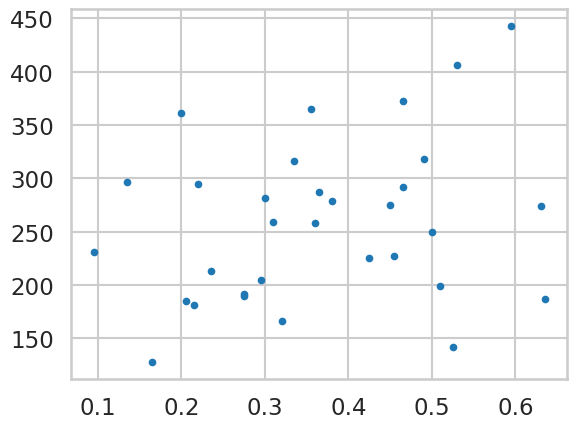

In [264]:
plt.plot(emd_emd["accuracy"],number_neurons,'.')

In [262]:
emd_emd = df[df['decoding']=="EMD → EMD"]

/tmp/ipykernel_3658531/2254597298.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


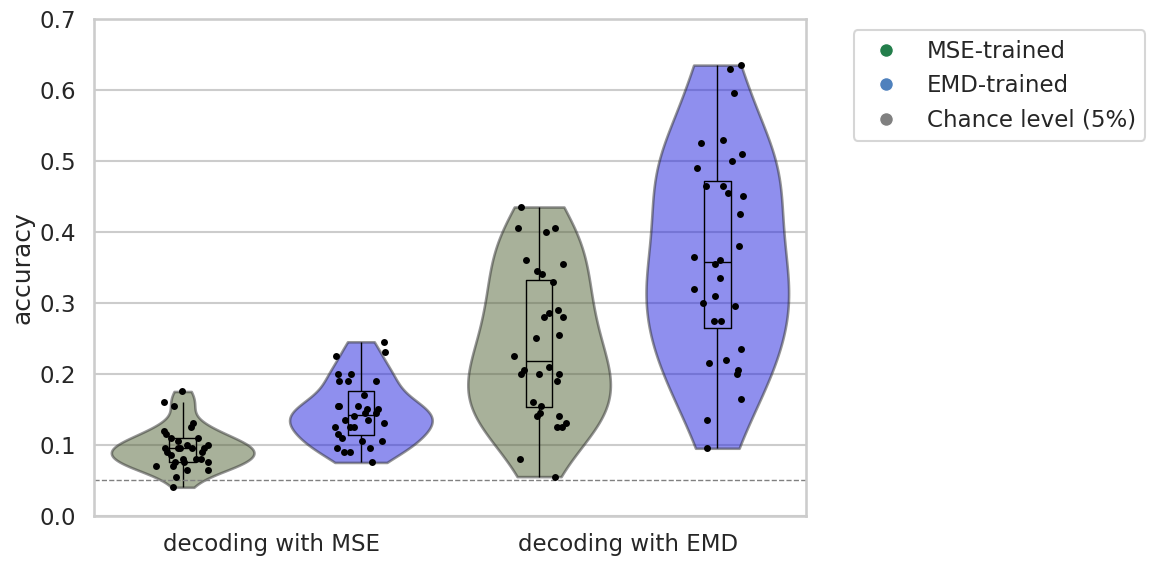

In [254]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("talk")

# Convert PyTorch tensors to numpy means across folds
def animal_mean(x):
    return x.mean(axis=0).detach().cpu().numpy()

# Prepare decoding data
data = {
    "MSE → MSE": animal_mean(acc_mse_mse),
    "MSE → EMD": animal_mean(acc_emd_mse),
    "EMD → MSE": animal_mean(acc_mse_emd),
    "EMD → EMD": animal_mean(acc_emd_emd),
    "FR baseline": animal_mean(acc_mse_frs),
    "EMD shuffled": animal_mean(acc_emd_emd_shuf)
}

rows = []
for label, vals in data.items():
    for i,v in enumerate(vals):
        rows.append({"decoding":label, "animal":i, "accuracy":float(v)})
df = pd.DataFrame(rows)

# Colour palette
palette = {
    "MSE → MSE": "darkolivegreen",
    "MSE → EMD": "darkolivegreen",
    "EMD → MSE": "blue",
    "EMD → EMD": "blue",
    "FR baseline": "#FFC000",
    "EMD shuffled": "#9AD1D4"
}

fig, ax = plt.subplots(figsize=(12, 6))

order = [
    "MSE → MSE",
    "EMD → MSE",
    "MSE → EMD",
    "EMD → EMD"
]#,"FR baseline","EMD shuffled"


# Violin plots (trimmed to real range)
sns.violinplot(
    data=df,
    x="decoding",
    y="accuracy",
    order=order,
    palette=palette,
    cut=0,
    inner=None,
    ax=ax
)
for patch in ax.collections:
    patch.set_alpha(0.5)

# Box plots (median & quartiles)
sns.boxplot(
    data=df,
    x="decoding",
    y="accuracy",
    order=order,
    width=0.15,
    showcaps=False,
    fill=False,
    color='black',
    linewidth=1,
    #boxprops={'facecolor':'white'},
    showfliers=False,
    ax=ax
)

# Individual animal points
sns.stripplot(
    data=df,
    x="decoding",
    y="accuracy",
    order=order,
    color="black",
    size=5,
    jitter=0.15,
    ax=ax
)

# Y-axis limits
ax.set_ylim(0,.7)

# Annotate chance level with legend text
chance = 0.05
ax.axhline(chance, linestyle="--", color="gray", linewidth=1)

# Axis labels & title
ax.set_xticks([0.5,2.5])#, rotation=0, ha="right")
ax.set_xticklabels(['decoding with MSE', 'decoding with EMD'])#, rotation=0, ha="right")
ax.set_xlabel("")
ax.set_ylabel("accuracy")
#ax.set_title("Decoding performance\nfor different training/decoding configurations")

# Custom legend (training loss & baseline)
legend_handles = [
    plt.Line2D([0],[0], marker='o', color='w', label='MSE-trained', markerfacecolor="#237E4B", markersize=10),
    plt.Line2D([0],[0], marker='o', color='w', label='EMD-trained', markerfacecolor="#4F81BD", markersize=10),
    #plt.Line2D([0],[0], marker='o', color='w', label='FR baseline (orange)', markerfacecolor="#FFC000", markersize=10),
    plt.Line2D([0],[0], marker='o', color='w', label='Chance level (5%)', markerfacecolor="gray", markersize=10)
]
ax.legend(
    handles=legend_handles,
    title="",
    bbox_to_anchor=(1.05,1),
    loc="upper left",
    frameon = True,
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3658531/661130203.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


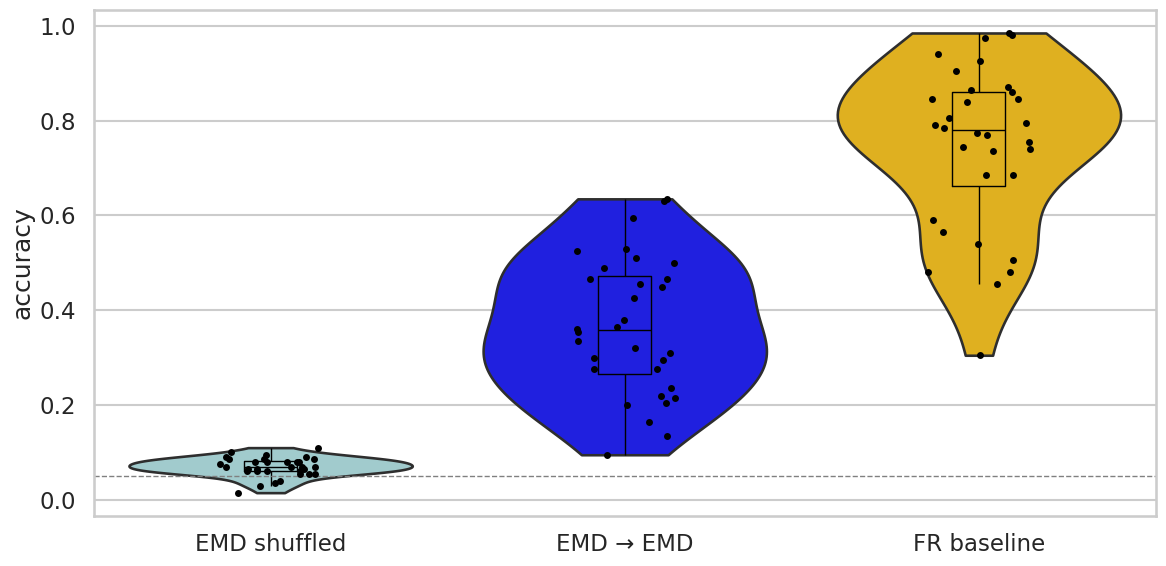

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("talk")

# Convert PyTorch tensors to numpy means across folds
def animal_mean(x):
    return x.mean(axis=0).detach().cpu().numpy()

# Prepare decoding data
data = {
    "MSE → MSE": animal_mean(acc_mse_mse),
    "MSE → EMD": animal_mean(acc_emd_mse),
    "EMD → MSE": animal_mean(acc_mse_emd),
    "EMD → EMD": animal_mean(acc_emd_emd),
    "FR baseline": animal_mean(acc_mse_frs),
    "EMD shuffled": animal_mean(acc_emd_emd_shuf)
}

rows = []
for label, vals in data.items():
    for i,v in enumerate(vals):
        rows.append({"decoding":label, "animal":i, "accuracy":float(v)})
df = pd.DataFrame(rows)

# Colour palette
palette = {
    "MSE → MSE": "darkolivegreen",
    "MSE → EMD": "darkolivegreen",
    "EMD → MSE": "blue",
    "EMD → EMD": "blue",
    "FR baseline": "#FFC000",
    "EMD shuffled": "#9AD1D4"
}

fig, ax = plt.subplots(figsize=(12, 6))

order = [
    "EMD shuffled",
    "EMD → EMD",
    "FR baseline"
]#,"FR baseline","EMD shuffled"


# Violin plots (trimmed to real range)
sns.violinplot(
    data=df,
    x="decoding",
    y="accuracy",
    order=order,
    palette=palette,
    cut=0,
    inner=None,
    ax=ax
)

# Box plots (median & quartiles)
sns.boxplot(
    data=df,
    x="decoding",
    y="accuracy",
    order=order,
    width=0.15,
    showcaps=False,
    fill=False,
    color='black',
    linewidth=1,
    #boxprops={'facecolor':'white'},
    showfliers=False,
    ax=ax
)

# Individual animal points
sns.stripplot(
    data=df,
    x="decoding",
    y="accuracy",
    order=order,
    color="black",
    size=5,
    jitter=0.15,
    ax=ax
)

# Y-axis limits
#ax.set_ylim(0,.7)

# Annotate chance level with legend text
chance = 0.05
ax.axhline(chance, linestyle="--", color="gray", linewidth=1)

# Axis labels & title
#ax.set_xticks([0.5,2.5])#, rotation=0, ha="right")
#ax.set_xticklabels(['decoding with MSE', 'decoding with EMD'])#, rotation=0, ha="right")
ax.set_xlabel("")
ax.set_ylabel("accuracy")
#ax.set_title("Decoding performance\nfor different training/decoding configurations")

# Custom legend (training loss & baseline)
legend_handles = [
    plt.Line2D([0],[0], marker='o', color='w', label='MSE-trained', markerfacecolor="#237E4B", markersize=10),
    plt.Line2D([0],[0], marker='o', color='w', label='EMD-trained', markerfacecolor="#4F81BD", markersize=10),
    #plt.Line2D([0],[0], marker='o', color='w', label='FR baseline (orange)', markerfacecolor="#FFC000", markersize=10),
    plt.Line2D([0],[0], marker='o', color='w', label='Chance level (5%)', markerfacecolor="gray", markersize=10)
]

plt.tight_layout()
plt.show()

In [103]:
fig.savefig('../figures/allen_decoding_frs.pdf', bbox_inches = 'tight')

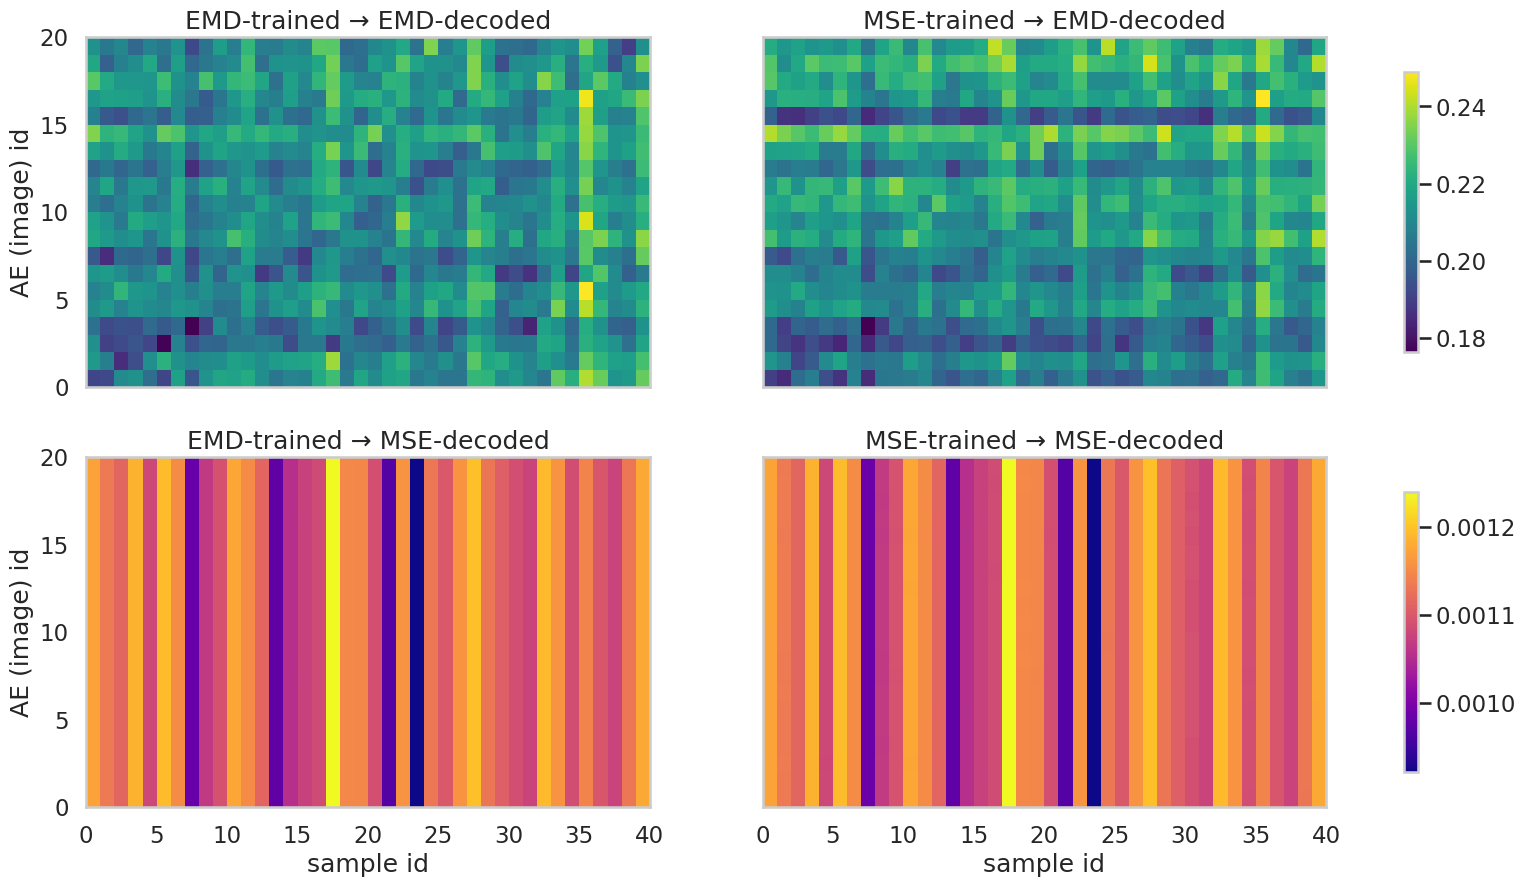

In [140]:
ind_fold = 0
ind_animal = 15
fig, axs = plt.subplots(2, 2,figsize=(20,10))
mat = [[all_emd_emd[ind_fold,ind_animal], all_emd_mse[ind_fold,ind_animal]],[all_mse_emd[ind_fold,ind_animal], all_mse_mse[ind_fold,ind_animal]]]
title = [["EMD-trained → EMD-decoded","MSE-trained → EMD-decoded"], ["EMD-trained → MSE-decoded","MSE-trained → MSE-decoded"]]

cmaps = ['viridis','plasma']
for row in range(2):
    for col in range(2):
        ax = axs[row, col]
        pcm = ax.pcolormesh(mat[row][col],
                            cmap=cmaps[row])
        if row==0:
            ax.set_xticks([])
        else:
            ax.set_xlabel('sample id')
        if col==1:
            ax.set_yticks([])
        else:
            ax.set_ylabel('AE (image) id')
        ax.set_title(title[row][col])
    fig.colorbar(pcm, ax=axs[row, :], shrink=0.8)

In [141]:
fig.savefig('../figures/decoding_losses_example.pdf', bbox_inches = 'tight')

/tmp/ipykernel_3658531/3049564068.py:40: UserWarning: Adding colorbar to a different Figure <Figure size 1700x500 with 14 Axes> than <Figure size 1200x500 with 3 Axes> which fig.colorbar is called on.
  fig.colorbar(pcm, cax=cax)


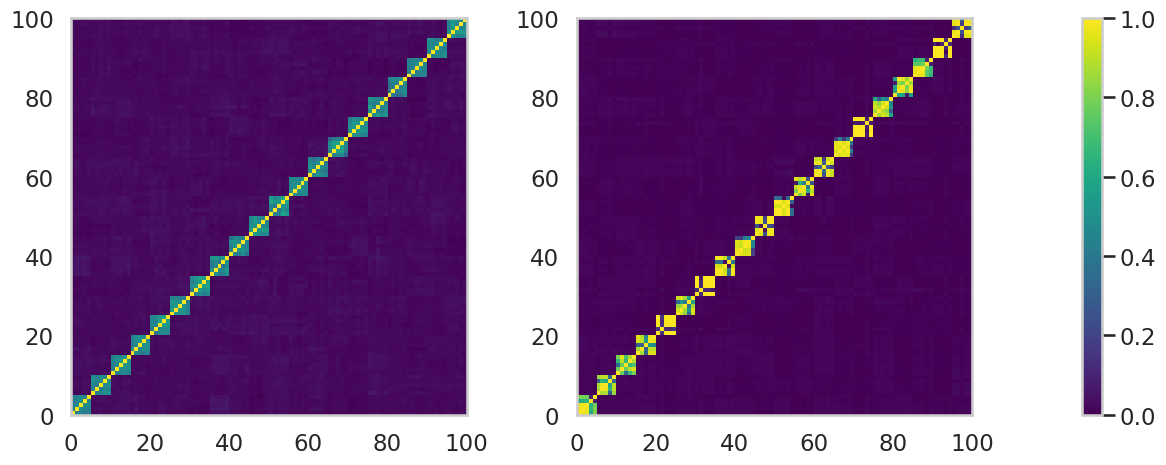

In [244]:
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

animal_id = 15

# ---- Figure layout (extra column for colorbar) ----
fig = plt.figure(figsize=(12,5))
gs = GridSpec(1, 3, width_ratios=[1,1,0.05], figure=fig)

ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
#ax2 = fig.add_subplot(gs[0,2])
cax = fig.add_subplot(gs[0,2])   # colorbar axis

# ---- Prepare data ----
n_images, n_neurons, n_timesteps = weights_emd[0][animal_id].shape
weights_e = torch.zeros([n_images*5,n_neurons,n_timesteps])
weights_m = torch.zeros([n_images*5,n_neurons,n_timesteps])

for f in range(len(weights_emd)):
    for i in range(n_images):
        weights_e[i*5+f] = weights_emd[f][animal_id][i]
        weights_m[i*5+f] = weights_mse[f][animal_id][i]

# ---- Plots ----
ax0.pcolormesh(
    weights_e.flatten(start_dim=1).corrcoef(),
    vmin=0, vmax=1, cmap='viridis'
)

ax1.pcolormesh(
    weights_m.flatten(start_dim=1).corrcoef(),
    vmin=0, vmax=1, cmap='viridis'
)

both_weights = torch.vstack([weights_e,weights_m])

# ---- Colorbar ----
fig.colorbar(pcm, cax=cax)

plt.tight_layout()
plt.show()

In [245]:
fig.savefig('../figures/correlation_kernels_example.pdf', bbox_inches = 'tight')

In [198]:
weights_emd[f][animal_id][image_number].shape

torch.Size([282, 250])

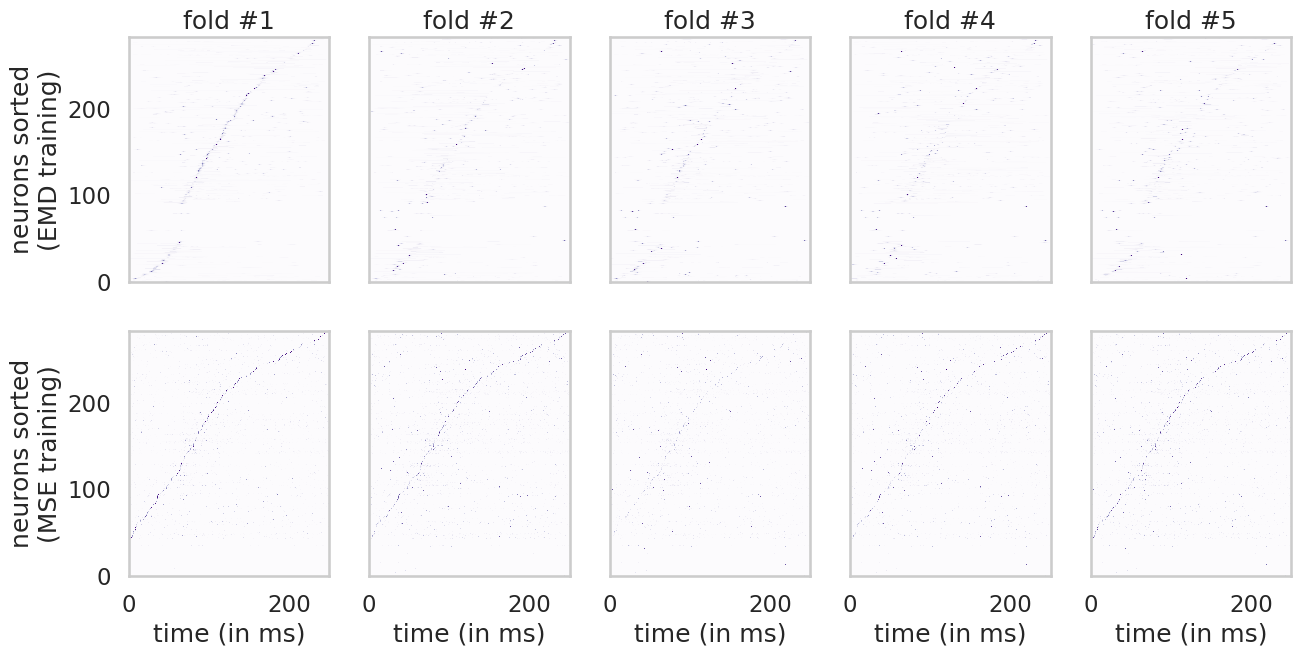

In [251]:
image_number = 2
fig, ax = plt.subplots(2,5,figsize=(15,7))
indices_e = weights_emd[0][animal_id][image_number].argmax(dim=1).argsort()
indices_m = weights_mse[0][animal_id][image_number].argmax(dim=1).argsort()

mul_emd = torch.ones_like(weights_emd[f][animal_id][image_number])
mul_mse = torch.ones_like(weights_mse[f][animal_id][image_number])
for f in range(5):
    ax[0,f].pcolormesh(weights_emd[f][animal_id][image_number][indices_e],cmap='Purples')
    ax[1,f].pcolormesh(weights_mse[f][animal_id][image_number][indices_m],cmap='Purples')
    ax[0,f].set_xticks([])
    ax[0,f].set_title(f'fold #{f+1}')
    if f > 0:
        ax[0,f].set_yticks([])
        ax[1,f].set_yticks([])
    ax[0,0].set_ylabel('neurons sorted\n(EMD training)')
    ax[1,0].set_ylabel('neurons sorted\n(MSE training)')
    ax[1,f].set_xlabel('time (in ms)')
    mul_emd *= weights_emd[f][animal_id][image_number][indices_e]
    mul_mse *= weights_mse[f][animal_id][image_number][indices_e]

In [253]:
fig.savefig('../figures/learned_weights_example.png', bbox_inches = 'tight')

/tmp/ipykernel_2799516/3342117298.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


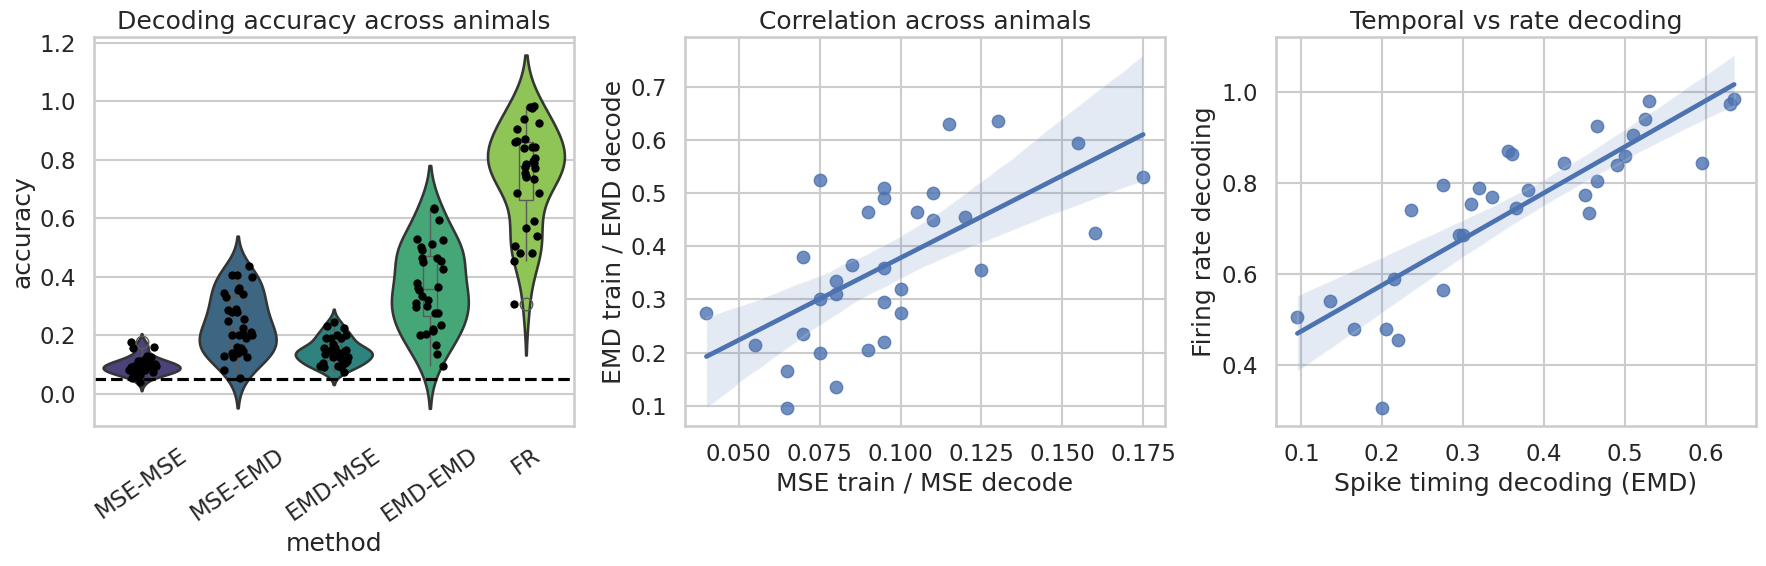

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("talk")

# convert tensors -> numpy
def animal_mean(x):
    return x.mean(axis=0).detach().cpu().numpy()

data = {
    "MSE-MSE": animal_mean(acc_mse_mse),
    "MSE-EMD": animal_mean(acc_emd_mse),
    "EMD-MSE": animal_mean(acc_mse_emd),
    "EMD-EMD": animal_mean(acc_emd_emd),
    "FR": animal_mean(acc_mse_frs),
}

rows = []
for method, vals in data.items():
    for i,v in enumerate(vals):
        rows.append({
            "method":method,
            "animal":i,
            "accuracy":float(v)
        })

df = pd.DataFrame(rows)

fig,axes = plt.subplots(1,3,figsize=(18,6))

order = ["MSE-MSE","MSE-EMD","EMD-MSE","EMD-EMD","FR"]

# PANEL A
sns.violinplot(
    data=df,
    x="method",
    y="accuracy",
    order=order,
    inner=None,
    palette="viridis",
    ax=axes[0]
)

sns.boxplot(
    data=df,
    x="method",
    y="accuracy",
    order=order,
    width=0.15,
    showcaps=False,
    boxprops={'facecolor':'none'},
    ax=axes[0]
)

sns.stripplot(
    data=df,
    x="method",
    y="accuracy",
    order=order,
    color="black",
    size=6,
    jitter=0.15,
    ax=axes[0]
)

axes[0].axhline(0.05,ls="--",color="black")
axes[0].set_title("Decoding accuracy across animals")
axes[0].tick_params(axis='x',rotation=35)

# PANEL B
x = data["MSE-MSE"]
y = data["EMD-EMD"]

sns.regplot(x=x,y=y,ax=axes[1],scatter_kws={"s":80})
axes[1].set_xlabel("MSE train / MSE decode")
axes[1].set_ylabel("EMD train / EMD decode")
axes[1].set_title("Correlation across animals")

# PANEL C
x = data["EMD-EMD"]
y = data["FR"]

sns.regplot(x=x,y=y,ax=axes[2],scatter_kws={"s":80})
axes[2].set_xlabel("Spike timing decoding (EMD)")
axes[2].set_ylabel("Firing rate decoding")
axes[2].set_title("Temporal vs rate decoding")

plt.tight_layout()
plt.show()